In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold





In [7]:
df=sns.load_dataset('iris')
le=LabelEncoder()
df['species']=le.fit_transform(df['species'])
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [44]:
lr=LinearRegression()
skf=StratifiedKFold()
dt=DecisionTreeClassifier()
rf=RandomForestRegressor()
sv=SVC()
logr=LogisticRegression()


model=[LinearRegression(),DecisionTreeClassifier(),RandomForestRegressor(),SVC(),LogisticRegression()]
model=[lr,dt,rf,sv,logr]


In [16]:
X=df.drop(['species'],axis='columns')
y=df['species']
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3



LinearRegression
0.9666666666666667
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


DecisionTreeClassifier
0.8666666666666667
[[15  0  0]
 [ 0 13  2]
 [ 0  2 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.87      0.87      0.87        15
           2       0.87      0.87      0.87        15

    accuracy                           0.91        45
   macro avg       0.91      0.91      0.91        45
weighted avg       0.91      0.91      0.91        45


RandomForestRegressor
0.9333333333333333
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]
     

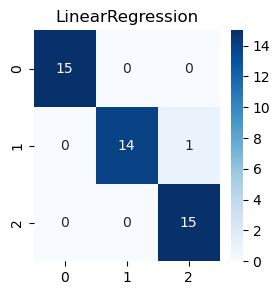

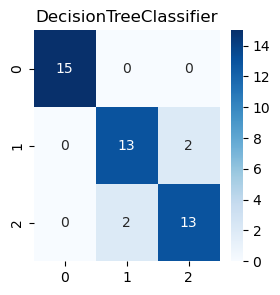

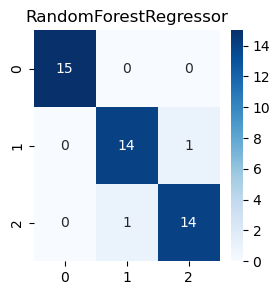

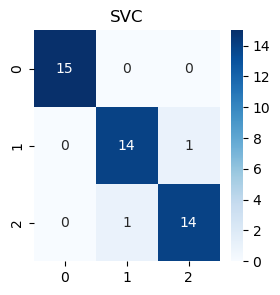

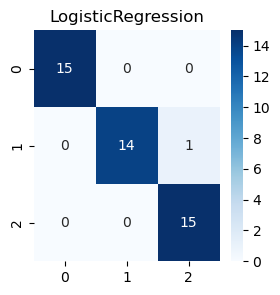

In [52]:
def mod(model,X,y):
    Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=123456)
    model.fit(Xtrain,ytrain)
    ypred=np.round(model.predict(Xtest))
    print(f"\n{model.__class__.__name__}")
    print(r2_score(ytest,ypred))
    cm=confusion_matrix(ytest,ypred)
    print(cm)
    cp=classification_report(ytest,ypred)
    print(cp)
    plt.figure(figsize=(3,3))
    plt.title(model.__class__.__name__)
    sns.heatmap(cm,annot=True,cmap='Blues')
    
for i in model:
    mod(i,X,y)

